## GRAD 504 Team Project
### Prediciting Electricity Demand Based on Weather

Group 5: Behnam Taghavi-Fard, Margaret Peacock, Matthew Yeung, and Srinivas R Sudala

### Approach: Train 2023, Validate 2024, Test 2025

#### Import & Load Data

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error
)

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

print("Libraries imported successfully.")

Libraries imported successfully.


In [61]:
# Load training and testing data

from pathlib import Path

data_path = Path(r"C:\Users\sunsh\GRAD504_TeamProject\data\final")

train_file = data_path / "dom_demand_va_weather_2023_2024_cleaned.csv"
test_file = data_path / "dom_demand_va_weather_2025.csv"

df_train = pd.read_csv(train_file)
df_test = pd.read_csv(test_file)

# Display basic information
print("Training data shape:", df_train.shape)
print("Testing data shape:", df_test.shape)

display(df_train.head())
display(df_test.head())

Training data shape: (17446, 16)
Testing data shape: (5088, 16)


,datetime,subregion_code,subregion_name,parent_code,parent_name,demand_mwh,value-units,air_temp_mean,air_temp_min,air_temp_max,dew_point_mean,sea_level_pressure_mean,wind_speed_mean,precip_1hr_mean,precip_1hr_max,station_count
0,2023-01-01 00:00:00,DOM,Dominion Virginia Power zone,PJM,"PJM Interconnection, LLC",12906,megawatthours,13.640000,10.0,17.9,12.583333,1011.790000,2.418182,NaN,NaN,11
1,2023-01-01 01:00:00,DOM,Dominion Virginia Power zone,PJM,"PJM Interconnection, LLC",12562,megawatthours,13.881081,7.8,18.9,13.150000,1011.966667,3.250000,1.460878,6.4,40
2,2023-01-01 02:00:00,DOM,Dominion Virginia Power zone,PJM,"PJM Interconnection, LLC",12188,megawatthours,13.778947,8.0,19.4,13.018182,1012.086364,3.527500,1.600004,7.1,40
3,2023-01-01 03:00:00,DOM,Dominion Virginia Power zone,PJM,"PJM Interconnection, LLC",11785,megawatthours,13.107895,6.8,19.4,12.369697,1012.141667,2.555000,0.926109,7.9,40
4,2023-01-01 04:00:00,DOM,Dominion Virginia Power zone,PJM,"PJM Interconnection, LLC",11428,megawatthours,12.241176,7.8,17.2,11.769697,1012.040000,2.605000,0.023565,0.2,40


,datetime,subregion_code,subregion_name,parent_code,parent_name,demand_mwh,value-units,air_temp_mean,air_temp_min,air_temp_max,dew_point_mean,sea_level_pressure_mean,wind_speed_mean,precip_1hr_mean,precip_1hr_max,station_count
0,2025-01-01 00:00:00,DOM,Dominion Virginia Power zone,PJM,"PJM Interconnection, LLC",14468,megawatthours,13.883333,8.9,17.3,9.828571,1001.591667,4.0750,NaN,NaN,12
1,2025-01-01 01:00:00,DOM,Dominion Virginia Power zone,PJM,"PJM Interconnection, LLC",14079,megawatthours,12.217500,4.0,17.8,7.973529,1002.034615,4.3550,0.142864,0.8000,40
2,2025-01-01 02:00:00,DOM,Dominion Virginia Power zone,PJM,"PJM Interconnection, LLC",13704,megawatthours,11.865000,2.8,18.3,7.514706,1002.065385,4.0225,0.000029,0.0001,40
3,2025-01-01 03:00:00,DOM,Dominion Virginia Power zone,PJM,"PJM Interconnection, LLC",13324,megawatthours,11.120000,2.0,17.2,7.225714,1001.961538,3.8900,0.157171,1.7000,40
4,2025-01-01 04:00:00,DOM,Dominion Virginia Power zone,PJM,"PJM Interconnection, LLC",13096,megawatthours,10.272500,1.0,16.2,6.908571,1002.300000,3.7400,1.153347,9.3000,40


In [62]:
# Limited validation of loaded data

# Convert datetime fields
df_train["datetime"] = pd.to_datetime(df_train["datetime"])
df_test["datetime"] = pd.to_datetime(df_test["datetime"])

# Confirm date ranges
print("Training data date range:")
print("Start:", df_train["datetime"].min())
print("End:  ", df_train["datetime"].max())

print("\nTesting data date range:")
print("Start:", df_test["datetime"].min())
print("End:  ", df_test["datetime"].max())

# Confirm target variable exists
target_col = "demand_mwh"

print("\nTarget column check:")
print(f"'{target_col}' in training data:", target_col in df_train.columns)
print(f"'{target_col}' in testing data: ", target_col in df_test.columns)

# Confirm row counts
print("\nRow counts:")
print("Training rows:", len(df_train))
print("Testing rows: ", len(df_test))

# Check missing values only for columns with missing data
print("\nMissing values in training data:")
display(df_train.isna().sum()[df_train.isna().sum() > 0])

print("\nMissing values in testing data:")
display(df_test.isna().sum()[df_test.isna().sum() > 0])

Training data date range:
Start: 2023-01-01 00:00:00
End:   2024-12-31 23:00:00

Testing data date range:
Start: 2025-01-01 00:00:00
End:   2025-07-31 23:00:00

Target column check:
'demand_mwh' in training data: True
'demand_mwh' in testing data:  True

Row counts:
Training rows: 17446
Testing rows:  5088

Missing values in training data:


precip_1hr_mean    17
precip_1hr_max     17
dtype: int64


Missing values in testing data:


precip_1hr_mean    1
precip_1hr_max     1
dtype: int64

In [63]:
# Confirm expected modeling columns are available in both datasets
expected_cols = [
    "datetime",
    "demand_mwh",
    "air_temp_mean",
    "dew_point_mean",
    "sea_level_pressure_mean",
    "wind_speed_mean",
    "precip_1hr_mean"
]

missing_train_cols = [col for col in expected_cols if col not in df_train.columns]
missing_test_cols = [col for col in expected_cols if col not in df_test.columns]

print("Missing expected columns in training data:", missing_train_cols)
print("Missing expected columns in testing data: ", missing_test_cols)

Missing expected columns in training data: []
Missing expected columns in testing data:  []


#### Feature Engineering

In [64]:
# Create time-based features for the 2023-2024 data
df_train["hour_of_day"] = df_train["datetime"].dt.hour
df_train["month"] = df_train["datetime"].dt.month
df_train["weekday"] = df_train["datetime"].dt.dayofweek

# Create a weekend indicator
# Saturday = 5 and Sunday = 6
df_train["is_weekend"] = df_train["weekday"].isin([5, 6]).astype(int)


# Create time-based features for the 2025 data
df_test["hour_of_day"] = df_test["datetime"].dt.hour
df_test["month"] = df_test["datetime"].dt.month
df_test["weekday"] = df_test["datetime"].dt.dayofweek

# Create a weekend indicator
df_test["is_weekend"] = df_test["weekday"].isin([5, 6]).astype(int)

print("Time-based features created successfully.")

Time-based features created successfully.


In [65]:
# Display a sample of the new time-based features
display(
    df_train[
        ["datetime", "hour_of_day", "month", "weekday", "is_weekend", "demand_mwh"]
    ].head()
)

display(
    df_test[
        ["datetime", "hour_of_day", "month", "weekday", "is_weekend", "demand_mwh"]
    ].head()
)

,datetime,hour_of_day,month,weekday,is_weekend,demand_mwh
0,2023-01-01 00:00:00,0,1,6,1,12906
1,2023-01-01 01:00:00,1,1,6,1,12562
2,2023-01-01 02:00:00,2,1,6,1,12188
3,2023-01-01 03:00:00,3,1,6,1,11785
4,2023-01-01 04:00:00,4,1,6,1,11428


,datetime,hour_of_day,month,weekday,is_weekend,demand_mwh
0,2025-01-01 00:00:00,0,1,2,0,14468
1,2025-01-01 01:00:00,1,1,2,0,14079
2,2025-01-01 02:00:00,2,1,2,0,13704
3,2025-01-01 03:00:00,3,1,2,0,13324
4,2025-01-01 04:00:00,4,1,2,0,13096


In [66]:
# Define the target variable
target_col = "demand_mwh"

# Define the weather feature columns
weather_features = [
    "air_temp_mean",
    "dew_point_mean",
    "sea_level_pressure_mean",
    "wind_speed_mean",
    "precip_1hr_mean"
]

# Define the time-based feature columns
time_features = [
    "hour_of_day",
    "month",
    "weekday",
    "is_weekend"
]

# Combine all model feature columns
feature_cols = weather_features + time_features

print("Target variable:")
print(target_col)
print("\nFeature columns:")
print(feature_cols)

Target variable:
demand_mwh

Feature columns:
['air_temp_mean', 'dew_point_mean', 'sea_level_pressure_mean', 'wind_speed_mean', 'precip_1hr_mean', 'hour_of_day', 'month', 'weekday', 'is_weekend']


#### 2023/2024/2025 Split

In [67]:
# Create separate 2023 training, 2024 validation, and 2025 test datasets

df_train_2023 = df_train[df_train["datetime"].dt.year == 2023].copy()
df_validate_2024 = df_train[df_train["datetime"].dt.year == 2024].copy()
df_test_2025 = df_test.copy()

print("2023 training data shape:", df_train_2023.shape)
print("2024 validation data shape:", df_validate_2024.shape)
print("2025 test data shape:", df_test_2025.shape)

print("\n2023 date range:", df_train_2023["datetime"].min(), "to", df_train_2023["datetime"].max())
print("2024 date range:", df_validate_2024["datetime"].min(), "to", df_validate_2024["datetime"].max())
print("2025 date range:", df_test_2025["datetime"].min(), "to", df_test_2025["datetime"].max())

2023 training data shape: (8711, 20)
2024 validation data shape: (8735, 20)
2025 test data shape: (5088, 20)

2023 date range: 2023-01-01 00:00:00 to 2023-12-31 23:00:00
2024 date range: 2024-01-01 00:00:00 to 2024-12-31 23:00:00
2025 date range: 2025-01-01 00:00:00 to 2025-07-31 23:00:00


In [68]:
# Define X and y for the 2023 training set
X_train_2023 = df_train_2023[feature_cols]
y_train_2023 = df_train_2023[target_col]

# Define X and y for the 2024 validation set
X_validate_2024 = df_validate_2024[feature_cols]
y_validate_2024 = df_validate_2024[target_col]

# Define X and y for the 2025 test set
X_test_2025 = df_test_2025[feature_cols]
y_test_2025 = df_test_2025[target_col]

print("X_train_2023 shape:", X_train_2023.shape)
print("y_train_2023 shape:", y_train_2023.shape)

print("\nX_validate_2024 shape:", X_validate_2024.shape)
print("y_validate_2024 shape:", y_validate_2024.shape)

print("\nX_test_2025 shape:", X_test_2025.shape)
print("y_test_2025 shape:", y_test_2025.shape)

X_train_2023 shape: (8711, 9)
y_train_2023 shape: (8711,)

X_validate_2024 shape: (8735, 9)
y_validate_2024 shape: (8735,)

X_test_2025 shape: (5088, 9)
y_test_2025 shape: (5088,)


In [69]:
# Confirm the time-based training, validation, and testing split
print("Training set - 2023:")
print("Date range:", df_train_2023["datetime"].min(), "to", df_train_2023["datetime"].max())
print("Rows:", len(df_train_2023))
print("Feature shape:", X_train_2023.shape)
print("Target shape:", y_train_2023.shape)

print("\nValidation set - 2024:")
print("Date range:", df_validate_2024["datetime"].min(), "to", df_validate_2024["datetime"].max())
print("Rows:", len(df_validate_2024))
print("Feature shape:", X_validate_2024.shape)
print("Target shape:", y_validate_2024.shape)

print("\nTesting set - 2025:")
print("Date range:", df_test_2025["datetime"].min(), "to", df_test_2025["datetime"].max())
print("Rows:", len(df_test_2025))
print("Feature shape:", X_test_2025.shape)
print("Target shape:", y_test_2025.shape)


# Separate the feature columns by type
numeric_features = [
    "air_temp_mean",
    "dew_point_mean",
    "sea_level_pressure_mean",
    "wind_speed_mean",
    "precip_1hr_mean"
]

categorical_features = [
    "hour_of_day",
    "month",
    "weekday",
    "is_weekend"
]

print("\nNumeric features:")
print(numeric_features)
print("\nCategorical features:")
print(categorical_features)

Training set - 2023:
Date range: 2023-01-01 00:00:00 to 2023-12-31 23:00:00
Rows: 8711
Feature shape: (8711, 9)
Target shape: (8711,)

Validation set - 2024:
Date range: 2024-01-01 00:00:00 to 2024-12-31 23:00:00
Rows: 8735
Feature shape: (8735, 9)
Target shape: (8735,)

Testing set - 2025:
Date range: 2025-01-01 00:00:00 to 2025-07-31 23:00:00
Rows: 5088
Feature shape: (5088, 9)
Target shape: (5088,)

Numeric features:
['air_temp_mean', 'dew_point_mean', 'sea_level_pressure_mean', 'wind_speed_mean', 'precip_1hr_mean']

Categorical features:
['hour_of_day', 'month', 'weekday', 'is_weekend']


#### Preprocessing Pipeline

In [70]:
# Create preprocessing steps for numeric and categorical features
# Numeric weather features:
# Fill missing values with the median, then scale the values
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Categorical time-based features:
# Convert categories into indicator columns
categorical_transformer = Pipeline(
    steps=[
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Combine numeric and categorical preprocessing into one pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features)
    ]
)
print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


### Linear Regression

In [71]:
linear_model_alt = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

# Train the model on 2023 data and track training time
start_time = time.time()

linear_model_alt.fit(X_train_2023, y_train_2023)

linear_training_time_alt = time.time() - start_time

print("Linear regression model trained on 2023 data successfully.")
print(f"Training time: {linear_training_time_alt:.4f} seconds")

Linear regression model trained on 2023 data successfully.
Training time: 0.0377 seconds


In [72]:
# Generate linear regression predictions for the 2024 validation data
y_pred_linear_2024 = linear_model_alt.predict(X_validate_2024)

# Evaluate linear regression on 2024 validation data
linear_2024_r2 = r2_score(y_validate_2024, y_pred_linear_2024)
linear_2024_mse = mean_squared_error(y_validate_2024, y_pred_linear_2024)
linear_2024_rmse = np.sqrt(linear_2024_mse)
linear_2024_mae = mean_absolute_error(y_validate_2024, y_pred_linear_2024)
linear_2024_mape = mean_absolute_percentage_error(y_validate_2024, y_pred_linear_2024)
linear_2024_bias = np.mean(y_pred_linear_2024 - y_validate_2024)
print("Linear Regression Validation Metrics - 2024")
print("-------------------------------------------")
print(f"R-squared: {linear_2024_r2:.4f}")
print(f"MSE:       {linear_2024_mse:.2f}")
print(f"RMSE:      {linear_2024_rmse:.2f}")
print(f"MAE:       {linear_2024_mae:.2f}")
print(f"MAPE:      {linear_2024_mape:.4f}")
print(f"Bias:      {linear_2024_bias:.2f}")

Linear Regression Validation Metrics - 2024
-------------------------------------------
R-squared: 0.3515
MSE:       3707463.48
RMSE:      1925.48
MAE:       1397.65
MAPE:      0.0920
Bias:      -910.04


In [73]:
# Generate linear regression predictions for the 2025 test data
y_pred_linear_2025 = linear_model_alt.predict(X_test_2025)

# Evaluate linear regression on 2025 test data
linear_2025_r2 = r2_score(y_test_2025, y_pred_linear_2025)
linear_2025_mse = mean_squared_error(y_test_2025, y_pred_linear_2025)
linear_2025_rmse = np.sqrt(linear_2025_mse)
linear_2025_mae = mean_absolute_error(y_test_2025, y_pred_linear_2025)
linear_2025_mape = mean_absolute_percentage_error(y_test_2025, y_pred_linear_2025)
linear_2025_bias = np.mean(y_pred_linear_2025 - y_test_2025)

linear_2025_results_alt = {
    "Model": "Linear Regression",
    "Training Period": "2023",
    "Evaluation Period": "2025 Test",
    "R-squared": linear_2025_r2,
    "MSE": linear_2025_mse,
    "RMSE": linear_2025_rmse,
    "MAE": linear_2025_mae,
    "MAPE": linear_2025_mape,
    "Bias": linear_2025_bias,
    "Training Time (seconds)": linear_training_time_alt
}

print("Linear Regression Test Metrics - 2025")
print("-------------------------------------")
print(f"R-squared: {linear_2025_r2:.4f}")
print(f"MSE:       {linear_2025_mse:.2f}")
print(f"RMSE:      {linear_2025_rmse:.2f}")
print(f"MAE:       {linear_2025_mae:.2f}")
print(f"MAPE:      {linear_2025_mape:.4f}")
print(f"Bias:      {linear_2025_bias:.2f}")
print(f"Training Time: {linear_training_time_alt:.4f} seconds")

Linear Regression Test Metrics - 2025
-------------------------------------
R-squared: -0.2153
MSE:       9778887.28
RMSE:      3127.12
MAE:       2503.41
MAPE:      0.1503
Bias:      -2407.75
Training Time: 0.0377 seconds


### Polynomial Regression

In [74]:
# Tune polynomial ridge regression using 2024 as the validation year
degree_options = [1, 2, 3]
alpha_options = [0.1, 1.0, 10.0, 100.0]

tuning_results = []

for degree in degree_options:
    for alpha in alpha_options:
        
        # Create numeric preprocessing for this polynomial degree
        tuning_numeric_transformer = Pipeline(
            steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("polynomial", PolynomialFeatures(degree=degree, include_bias=False))
            ]
        )
        
        # Create categorical preprocessing
        tuning_categorical_transformer = Pipeline(
            steps=[
                ("encoder", OneHotEncoder(handle_unknown="ignore"))
            ]
        )
        
        # Combine numeric and categorical preprocessing
        tuning_preprocessor = ColumnTransformer(
            transformers=[
                ("numeric_poly", tuning_numeric_transformer, numeric_features),
                ("categorical", tuning_categorical_transformer, categorical_features)
            ]
        )
        
        # Create the full model pipeline
        tuning_model = Pipeline(
            steps=[
                ("preprocessor", tuning_preprocessor),
                ("model", Ridge(alpha=alpha))
            ]
        )
        
        # Train on 2023 data
        tuning_model.fit(X_train_2023, y_train_2023)
        
        # Evaluate on 2024 validation data
        y_pred_validate_2024 = tuning_model.predict(X_validate_2024)
        
        validation_r2 = r2_score(y_validate_2024, y_pred_validate_2024)
        validation_mse = mean_squared_error(y_validate_2024, y_pred_validate_2024)
        validation_rmse = np.sqrt(validation_mse)
        validation_mae = mean_absolute_error(y_validate_2024, y_pred_validate_2024)
        validation_mape = mean_absolute_percentage_error(y_validate_2024, y_pred_validate_2024)
        
        # Save results
        tuning_results.append({
            "Degree": degree,
            "Alpha": alpha,
            "Validation R-squared": validation_r2,
            "Validation MSE": validation_mse,
            "Validation RMSE": validation_rmse,
            "Validation MAE": validation_mae,
            "Validation MAPE": validation_mape
        })

# Convert results to a dataframe
tuning_results_df = pd.DataFrame(tuning_results)

# Sort by lowest validation RMSE
tuning_results_df = tuning_results_df.sort_values("Validation RMSE")

# Display rounded results
display(tuning_results_df.round(4))

,Degree,Alpha,Validation R-squared,Validation MSE,Validation RMSE,Validation MAE,Validation MAPE
10,3,10.0,0.8408,9.099985e+05,953.9384,772.7845,0.0533
9,3,1.0,0.8400,9.149336e+05,956.5216,775.7015,0.0537
8,3,0.1,0.8398,9.156927e+05,956.9183,776.0674,0.0537
11,3,100.0,0.8341,9.483676e+05,973.8417,775.6629,0.0527
6,2,10.0,0.8317,9.619826e+05,980.8071,787.3301,0.0542
5,2,1.0,0.8310,9.663992e+05,983.0560,789.6873,0.0545
4,2,0.1,0.8309,9.670595e+05,983.3918,789.9756,0.0545
7,2,100.0,0.8259,9.956488e+05,997.8221,789.0062,0.0534
2,1,10.0,0.3529,3.699485e+06,1923.4046,1393.1544,0.0915
1,1,1.0,0.3517,3.706278e+06,1925.1697,1397.0793,0.0919


In [75]:
# Select the best model settings based on the lowest validation RMSE
best_settings = tuning_results_df.iloc[0]

best_degree = int(best_settings["Degree"])
best_alpha = float(best_settings["Alpha"])

print("Best polynomial ridge regression settings based on 2024 validation RMSE")
print("---------------------------------------------------------------------")
print("Best degree:", best_degree)
print("Best alpha:", best_alpha)
print(f"Best validation R-squared: {best_settings['Validation R-squared']:.4f}")
print(f"Best validation RMSE:      {best_settings['Validation RMSE']:.2f}")
print(f"Best validation MSE:       {best_settings['Validation MSE']:.2f}")
print(f"Best validation MAE:       {best_settings['Validation MAE']:.2f}")
print(f"Best validation MAPE:      {best_settings['Validation MAPE']:.4f}")

Best polynomial ridge regression settings based on 2024 validation RMSE
---------------------------------------------------------------------
Best degree: 3
Best alpha: 10.0
Best validation R-squared: 0.8408
Best validation RMSE:      953.94
Best validation MSE:       909998.49
Best validation MAE:       772.78
Best validation MAPE:      0.0533


In [76]:
# Create the final polynomial preprocessing pipeline using the best degree
best_polynomial_numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("polynomial", PolynomialFeatures(degree=best_degree, include_bias=False))
    ]
)

best_polynomial_categorical_transformer = Pipeline(
    steps=[
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

best_polynomial_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric_poly", best_polynomial_numeric_transformer, numeric_features),
        ("categorical", best_polynomial_categorical_transformer, categorical_features)
    ]
)

# Create the final polynomial ridge regression model
polynomial_model = Pipeline(
    steps=[
        ("preprocessor", best_polynomial_preprocessor),
        ("model", Ridge(alpha=best_alpha))
    ]
)

# Train the selected model on 2023 data and track training time
start_time = time.time()

polynomial_model.fit(X_train_2023, y_train_2023)

polynomial_training_time = time.time() - start_time

print("Selected polynomial ridge regression model trained successfully.")
print(f"Best degree: {best_degree}")
print(f"Best alpha: {best_alpha}")
print(f"Training time: {polynomial_training_time:.4f} seconds")

Selected polynomial ridge regression model trained successfully.
Best degree: 3
Best alpha: 10.0
Training time: 0.0290 seconds


In [78]:
# Evaluate the selected polynomial model on 2024 validation data
y_pred_polynomial_2024 = polynomial_model.predict(X_validate_2024)

polynomial_2024_r2 = r2_score(y_validate_2024, y_pred_polynomial_2024)
polynomial_2024_mse = mean_squared_error(y_validate_2024, y_pred_polynomial_2024)
polynomial_2024_rmse = np.sqrt(polynomial_2024_mse)
polynomial_2024_mae = mean_absolute_error(y_validate_2024, y_pred_polynomial_2024)
polynomial_2024_mape = mean_absolute_percentage_error(y_validate_2024, y_pred_polynomial_2024)
polynomial_2024_bias = np.mean(y_pred_polynomial_2024 - y_validate_2024)

print("Selected Polynomial Ridge Regression Validation Metrics - 2024")
print("--------------------------------------------------------------")
print(f"R-squared: {polynomial_2024_r2:.4f}")
print(f"MSE:       {polynomial_2024_mse:.2f}")
print(f"RMSE:      {polynomial_2024_rmse:.2f}")
print(f"MAE:       {polynomial_2024_mae:.2f}")
print(f"MAPE:      {polynomial_2024_mape:.4f}")
print(f"Bias:      {polynomial_2024_bias:.2f}")

Selected Polynomial Ridge Regression Validation Metrics - 2024
--------------------------------------------------------------
R-squared: 0.8408
MSE:       909998.49
RMSE:      953.94
MAE:       772.78
MAPE:      0.0533
Bias:      -699.83


In [80]:
# Test the selected polynomial model on the available 2025 data
y_pred_polynomial_2025 = polynomial_model.predict(X_test_2025)

polynomial_2025_r2 = r2_score(y_test_2025, y_pred_polynomial_2025)
polynomial_2025_mse = mean_squared_error(y_test_2025, y_pred_polynomial_2025)
polynomial_2025_rmse = np.sqrt(polynomial_2025_mse)
polynomial_2025_mae = mean_absolute_error(y_test_2025, y_pred_polynomial_2025)
polynomial_2025_mape = mean_absolute_percentage_error(y_test_2025, y_pred_polynomial_2025)
polynomial_2025_bias = np.mean(y_pred_polynomial_2025 - y_test_2025)

polynomial_2025_results = {
    "Model": "Polynomial Ridge Regression",
    "Training Period": "2023",
    "Validation Period": "2024",
    "Test Period": "2025",
    "Best Degree": best_degree,
    "Best Alpha": best_alpha,
    "R-squared": polynomial_2025_r2,
    "MSE": polynomial_2025_mse,
    "RMSE": polynomial_2025_rmse,
    "MAE": polynomial_2025_mae,
    "MAPE": polynomial_2025_mape,
    "Bias": polynomial_2025_bias,
    "Training Time (seconds)": polynomial_training_time
}

print("Selected Polynomial Ridge Regression Test Metrics - 2025")
print("--------------------------------------------------------")
print(f"R-squared: {polynomial_2025_r2:.4f}")
print(f"MSE:       {polynomial_2025_mse:.2f}")
print(f"RMSE:      {polynomial_2025_rmse:.2f}")
print(f"MAE:       {polynomial_2025_mae:.2f}")
print(f"MAPE:      {polynomial_2025_mape:.4f}")
print(f"Bias:      {polynomial_2025_bias:.2f}")
print(f"Training Time: {polynomial_training_time:.4f} seconds")

Selected Polynomial Ridge Regression Test Metrics - 2025
--------------------------------------------------------
R-squared: 0.5702
MSE:       3458086.30
RMSE:      1859.59
MAE:       1719.71
MAPE:      0.1106
Bias:      -1718.18
Training Time: 0.0290 seconds


### Results Comparison

In [81]:
# Create a comparison table for the 2023 / 2024 / 2025 approach
alternative_split_results = pd.DataFrame([
    {
        "Model": "Linear Regression",
        "Training Period": "2023",
        "Evaluation Period": "2024 Validation",
        "Best Degree": None,
        "Best Alpha": None,
        "R-squared": linear_2024_r2,
        "MSE": linear_2024_mse,
        "RMSE": linear_2024_rmse,
        "MAE": linear_2024_mae,
        "MAPE": linear_2024_mape,
        "Bias": linear_2024_bias,
        "Training Time (seconds)": linear_training_time_alt
    },
    {
        "Model": "Polynomial Ridge Regression",
        "Training Period": "2023",
        "Evaluation Period": "2024 Validation",
        "Best Degree": best_degree,
        "Best Alpha": best_alpha,
        "R-squared": polynomial_2024_r2,
        "MSE": polynomial_2024_mse,
        "RMSE": polynomial_2024_rmse,
        "MAE": polynomial_2024_mae,
        "MAPE": polynomial_2024_mape,
        "Bias": polynomial_2024_bias,
        "Training Time (seconds)": polynomial_training_time
    },
    linear_2025_results_alt,
    polynomial_2025_results
])

# Round the results for easier reading
alternative_split_results_rounded = alternative_split_results.copy()

alternative_split_results_rounded["R-squared"] = alternative_split_results_rounded["R-squared"].round(4)
alternative_split_results_rounded["MSE"] = alternative_split_results_rounded["MSE"].round(2)
alternative_split_results_rounded["RMSE"] = alternative_split_results_rounded["RMSE"].round(2)
alternative_split_results_rounded["MAE"] = alternative_split_results_rounded["MAE"].round(2)
alternative_split_results_rounded["MAPE"] = alternative_split_results_rounded["MAPE"].round(4)
alternative_split_results_rounded["Bias"] = alternative_split_results_rounded["Bias"].round(2)
alternative_split_results_rounded["Training Time (seconds)"] = alternative_split_results_rounded["Training Time (seconds)"].round(4)

display(alternative_split_results_rounded)

,Model,Training Period,Evaluation Period,Best Degree,Best Alpha,R-squared,MSE,RMSE,MAE,MAPE,Bias,Training Time (seconds),Validation Period,Test Period
0,Linear Regression,2023,2024 Validation,NaN,NaN,0.3515,3707463.48,1925.48,1397.65,0.0920,-910.04,0.0377,NaN,NaN
1,Polynomial Ridge Regression,2023,2024 Validation,3.0,10.0,0.8408,909998.49,953.94,772.78,0.0533,-699.83,0.0290,NaN,NaN
2,Linear Regression,2023,2025 Test,NaN,NaN,-0.2153,9778887.28,3127.12,2503.41,0.1503,-2407.75,0.0377,NaN,NaN
3,Polynomial Ridge Regression,2023,NaN,3.0,10.0,0.5702,3458086.30,1859.59,1719.71,0.1106,-1718.18,0.0290,2024,2025


In [82]:
# Calculate improvement from linear regression to polynomial ridge regression
r2_change_2024 = polynomial_2024_r2 - linear_2024_r2
mse_change_2024 = linear_2024_mse - polynomial_2024_mse
mse_percent_change_2024 = (mse_change_2024 / linear_2024_mse) * 100

r2_change_2025 = polynomial_2025_r2 - linear_2025_r2
mse_change_2025 = linear_2025_mse - polynomial_2025_mse
mse_percent_change_2025 = (mse_change_2025 / linear_2025_mse) * 100

print("Improvement from Linear Regression to Polynomial Ridge Regression")
print("----------------------------------------------------------------")
print("2024 Validation:")
print(f"R-squared change:     {r2_change_2024:.4f}")
print(f"MSE change:           {mse_change_2024:.2f}")
print(f"MSE percent change:   {mse_percent_change_2024:.2f}%")

print("\n2025 Test:")
print(f"R-squared change:     {r2_change_2025:.4f}")
print(f"MSE change:           {mse_change_2025:.2f}")
print(f"MSE percent change:   {mse_percent_change_2025:.2f}%")

Improvement from Linear Regression to Polynomial Ridge Regression
----------------------------------------------------------------
2024 Validation:
R-squared change:     0.4893
MSE change:           2797464.99
MSE percent change:   75.45%

2025 Test:
R-squared change:     0.7855
MSE change:           6320800.98
MSE percent change:   64.64%


In [83]:
# Create a dataframe with 2025 actual values and predictions from the alternative split models
alternative_results_2025 = pd.DataFrame({
    "datetime": df_test_2025["datetime"],
    "actual_demand": y_test_2025,
    "linear_prediction": y_pred_linear_2025,
    "polynomial_prediction": y_pred_polynomial_2025
})

# Calculate residuals
alternative_results_2025["linear_residual"] = (
    alternative_results_2025["actual_demand"] - alternative_results_2025["linear_prediction"]
)
alternative_results_2025["polynomial_residual"] = (
    alternative_results_2025["actual_demand"] - alternative_results_2025["polynomial_prediction"]
)
display(alternative_results_2025.head())

,datetime,actual_demand,linear_prediction,polynomial_prediction,linear_residual,polynomial_residual
0,2025-01-01 00:00:00,14468,14360.591021,13713.018593,107.408979,754.981407
1,2025-01-01 01:00:00,14079,14238.235255,13763.833602,-159.235255,315.166398
2,2025-01-01 02:00:00,13704,13804.127847,13340.015191,-100.127847,363.984809
3,2025-01-01 03:00:00,13324,13210.547274,12900.514416,113.452726,423.485584
4,2025-01-01 04:00:00,13096,12722.489559,12693.978050,373.510441,402.021950


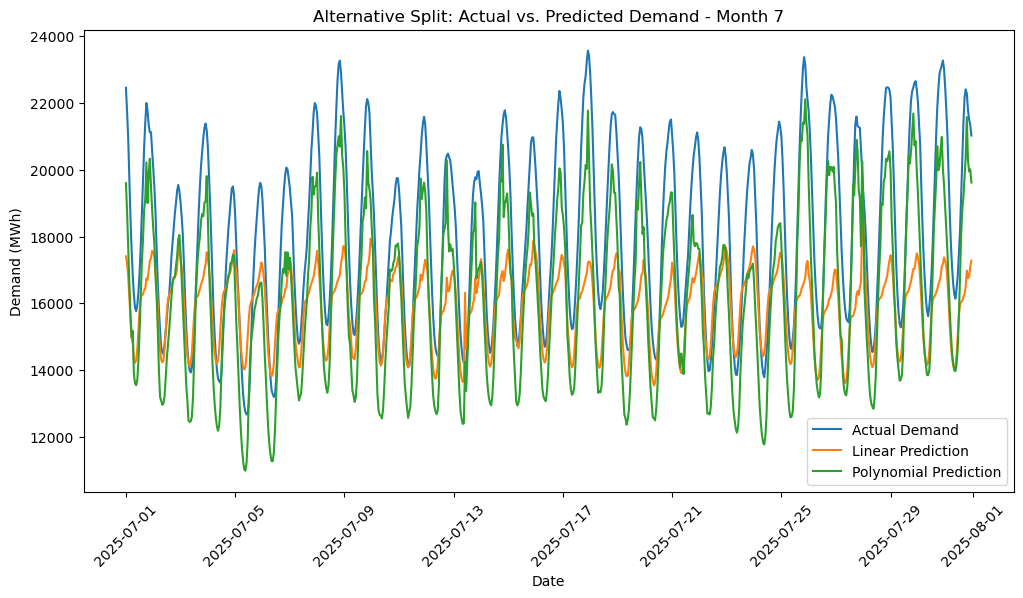

In [84]:
# Plot actual and predicted demand over one selected month in 2025
selected_month = 7

monthly_results_alt = alternative_results_2025[
    alternative_results_2025["datetime"].dt.month == selected_month
]

plt.figure(figsize=(12, 6))
plt.plot(monthly_results_alt["datetime"], monthly_results_alt["actual_demand"], label="Actual Demand")
plt.plot(monthly_results_alt["datetime"], monthly_results_alt["linear_prediction"], label="Linear Prediction")
plt.plot(monthly_results_alt["datetime"], monthly_results_alt["polynomial_prediction"], label="Polynomial Prediction")
plt.xlabel("Date")
plt.ylabel("Demand (MWh)")
plt.title(f"Alternative Split: Actual vs. Predicted Demand - Month {selected_month}")
plt.legend()
plt.xticks(rotation=45)
plt.show()

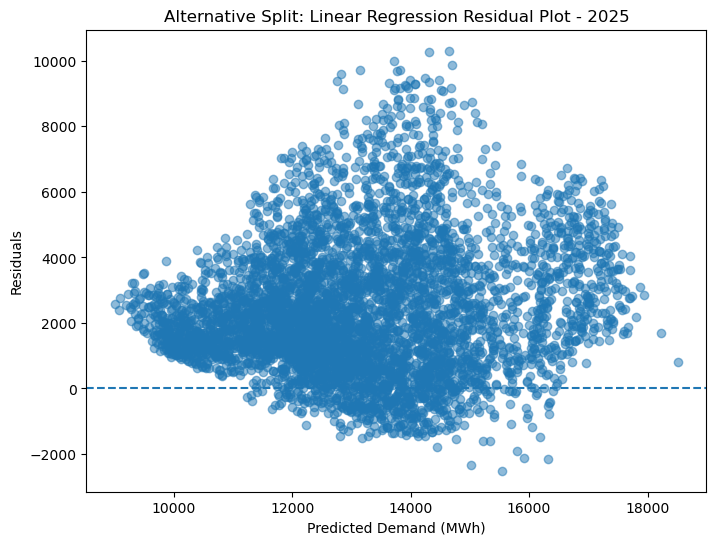

In [85]:
# Residual plot for the linear regression model
plt.figure(figsize=(8, 6))
plt.scatter(
    alternative_results_2025["linear_prediction"],
    alternative_results_2025["linear_residual"],
    alpha=0.5
)

plt.axhline(y=0, linestyle="--")
plt.xlabel("Predicted Demand (MWh)")
plt.ylabel("Residuals")
plt.title("Alternative Split: Linear Regression Residual Plot - 2025")
plt.show()

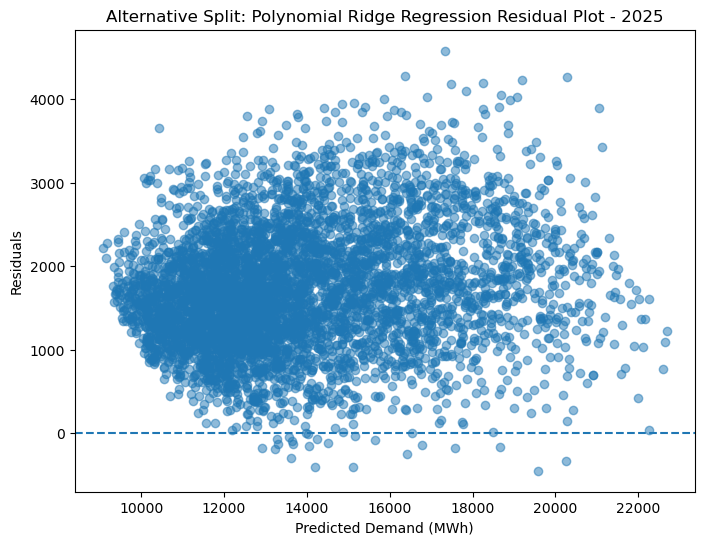

In [86]:
# Residual plot for the polynomial ridge regression model
plt.figure(figsize=(8, 6))

plt.scatter(
    alternative_results_2025["polynomial_prediction"],
    alternative_results_2025["polynomial_residual"],
    alpha=0.5
)
plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Demand (MWh)")
plt.ylabel("Residuals")
plt.title("Alternative Split: Polynomial Ridge Regression Residual Plot - 2025")
plt.show()